# 01 — CAPE–shear joint climate (A1)
The confounder map: feature density in (CAPE, shear) space, land vs ocean. Establishes the sampling and the regime anticorrelation that makes raw shear–intensity correlations misleading — hence the fixed-CAPE conditioning in 02–05.

In [1]:
import sys; sys.path.insert(0, '.')
from _shc import *
con = connect()


FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

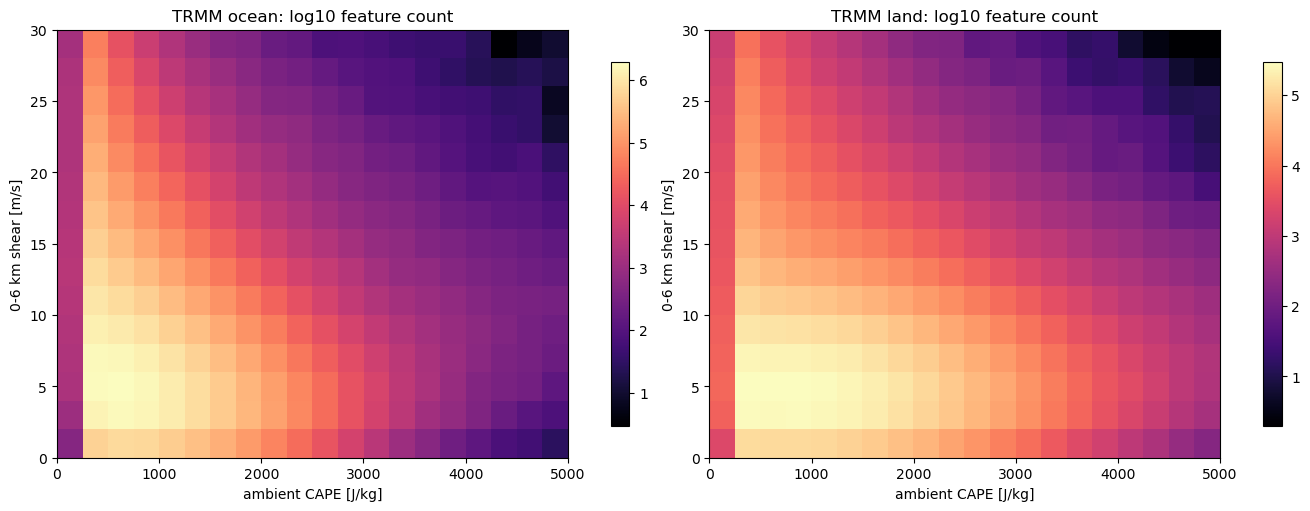

/data/NASA/a/snesbitt/pip_tmp/ipykernel_444071/2441661736.py:6: RuntimeWarning: divide by zero encountered in log10
  im = ax.imshow(np.log10(np.ma.masked_equal(N,0)),origin='lower',aspect='auto',extent=ext,cmap='magma')


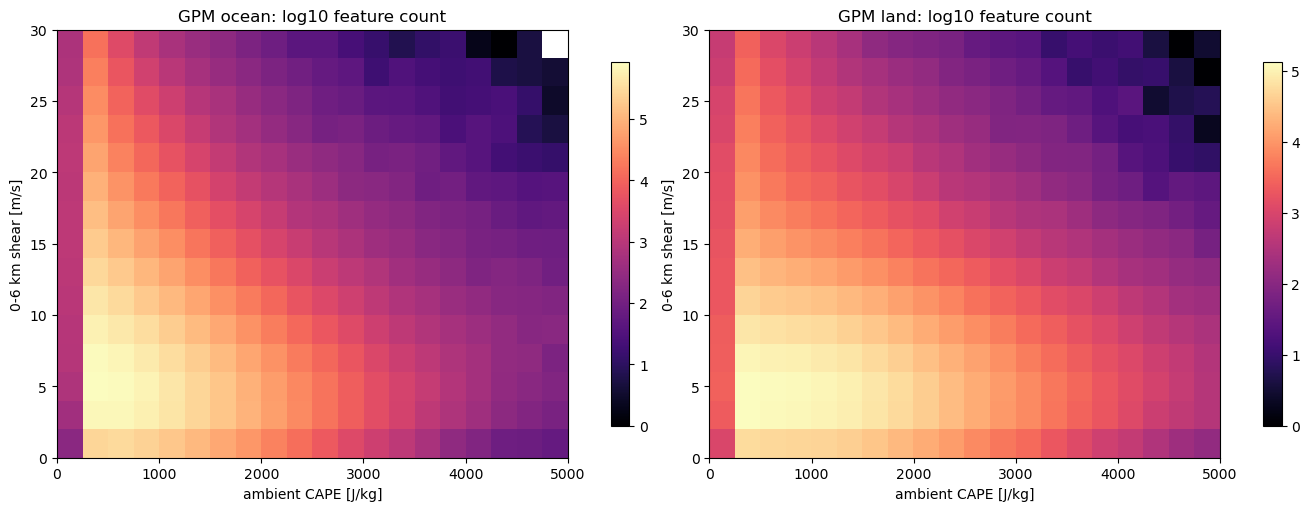

In [2]:
import numpy as np
for mission in ['TRMM','GPM']:
    fig, axes = plt.subplots(1,2,figsize=(13,5),constrained_layout=True)
    for ax,surf in zip(axes,['ocean','land']):
        G,N,ext = composite_2d(con,'area_km2',mission=mission,surf=surf,stat='median',conv_only=False)
        im = ax.imshow(np.log10(np.ma.masked_equal(N,0)),origin='lower',aspect='auto',extent=ext,cmap='magma')
        ax.set_xlabel('ambient CAPE [J/kg]'); ax.set_ylabel('0-6 km shear [m/s]')
        ax.set_title(f'{mission} {surf}: log10 feature count'); fig.colorbar(im,ax=ax,shrink=.85)
    plt.show()